In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load Data

In [10]:
df = pd.read_csv(r"C:\Users\faraz\Downloads\Sales_and_Customer_data.csv")

#### Inspection

In [11]:
df.head()

,Customer_ID,Product_ID,Transaction_ID,Purchase_Frequency,Average_Order_Value,Most_Frequent_Category,Time_Between_Purchases,Region,Churn_Probability,Lifetime_Value,Launch_Date,Peak_Sales_Date,Season,Preferred_Purchase_Times,Retention_Strategy
0,CUST_9HOS83,PROD_IK97D1,TRANS_II1DZG,17,172.57,Electronics,45,South America,0.98,952.81,14/03/2020,11/09/2023,Winter,Afternoon,Loyalty Program
1,CUST_AJU17N,PROD_UNN7KP,TRANS_9HJF7I,10,64.89,Clothing,6,South America,0.66,5427.51,15/10/2022,02/01/2023,Spring,Afternoon,Discount
2,CUST_11XNYF,PROD_0XEW2W,TRANS_OT96OM,3,120.38,Sports,23,Asia,0.60,3994.80,30/11/2021,06/04/2023,Winter,Evening,Loyalty Program
3,CUST_IGH8G3,PROD_3IIAJN,TRANS_45V00G,12,70.34,Clothing,5,North America,0.78,4880.01,20/03/2022,23/03/2023,Spring,Evening,Discount
4,CUST_OK6PUM,PROD_VMIWD2,TRANS_ZAK760,18,42.39,Electronics,10,North America,0.52,8557.70,09/11/2022,28/10/2023,Spring,Morning,Discount


In [12]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 15)


In [15]:
print("\n---------- Column Info --------")
print(df.info())


---------- Column Info --------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               10000 non-null  object 
 1   Product_ID                10000 non-null  object 
 2   Transaction_ID            10000 non-null  object 
 3   Purchase_Frequency        10000 non-null  int64  
 4   Average_Order_Value       10000 non-null  float64
 5   Most_Frequent_Category    10000 non-null  object 
 6   Time_Between_Purchases    10000 non-null  int64  
 7   Region                    10000 non-null  object 
 8   Churn_Probability         10000 non-null  float64
 9   Lifetime_Value            10000 non-null  float64
 10  Launch_Date               10000 non-null  object 
 11  Peak_Sales_Date           10000 non-null  object 
 12  Season                    10000 non-null  object 
 13  Preferred_Purchase_Times  100

In [17]:
print("\n------ Missing Values Check ------")
print(df.isnull().sum())


------ Missing Values Check ------
Customer_ID                 0
Product_ID                  0
Transaction_ID              0
Purchase_Frequency          0
Average_Order_Value         0
Most_Frequent_Category      0
Time_Between_Purchases      0
Region                      0
Churn_Probability           0
Lifetime_Value              0
Launch_Date                 0
Peak_Sales_Date             0
Season                      0
Preferred_Purchase_Times    0
Retention_Strategy          0
dtype: int64


------------------------------------------------------------------------------------

*The dataset contains 10,000 records and 15 columns. There are zero missing values across all parameters, meaning the data is clean and ready for further statistical profiling.*

---------------------------------------------------------------------------------------------------------------

### Descriptive Statistics

In [32]:
desc_stats = df.describe()
print("Descriptive Statistics:\n", desc_stats)

Descriptive Statistics:
        Purchase_Frequency  Average_Order_Value  Time_Between_Purchases  \
count        10000.000000         10000.000000            10000.000000   
mean             9.955700           110.006022               46.885300   
std              5.526209            52.096870               24.711746   
min              1.000000            20.010000                5.000000   
25%              5.000000            65.262500               25.000000   
50%             10.000000           109.930000               47.000000   
75%             15.000000           155.480000               68.000000   
max             19.000000           199.960000               89.000000   

       Churn_Probability  Lifetime_Value  
count       10000.000000    10000.000000  
mean            0.501552     5031.930567  
std             0.288289     2865.420299  
min             0.000000      100.160000  
25%             0.250000     2518.775000  
50%             0.500000     5012.180000  
75%    

In [33]:
modes = df.select_dtypes(include=[np.number]).mode().iloc[0]
print("\nModes of Numerical Columns:\n", modes)


Modes of Numerical Columns:
 Purchase_Frequency          1.00
Average_Order_Value        26.74
Time_Between_Purchases     74.00
Churn_Probability           0.84
Lifetime_Value            138.63
Name: 0, dtype: float64


----------------------------------------------------------------------------------

*The average purchase frequency is around 10 times, with an average order value close to 110. The average Customer Lifetime Value (LTV) sits at approximately $5,031.93.*

-------------------------------------------------------------------------------------

### Time Series Analysis

In [34]:
df['Peak_Sales_Date'] = pd.to_datetime(df['Peak_Sales_Date'], format='%d/%m/%Y')

In [35]:
df['Year_Month'] = df['Peak_Sales_Date'].dt.to_period('M')
df['Quarter'] = df['Peak_Sales_Date'].dt.to_period('Q')

In [36]:
monthly_trends = df.groupby('Year_Month')['Average_Order_Value'].sum()

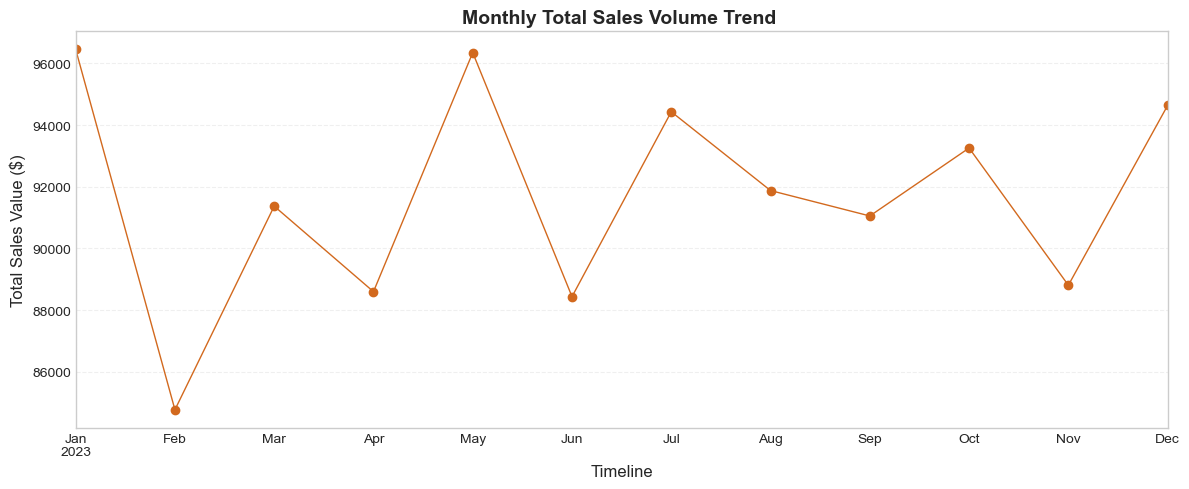

In [65]:
plt.figure(figsize=(12, 5))
monthly_trends.plot(kind='line', marker='o', color='#D2691E', linewidth=1)
plt.title('Monthly Total Sales Volume Trend ', fontsize=14,fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales Value ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png')

-------------

*Based on image_43d65e.png, the line chart shows a highly volatile monthly sales trend throughout the year. Peak sales are recorded in January and May (both crossing 96,000), while the sharpest decline occurs in February, dropping to the year's lowest point at around 85,000. Despite frequent fluctuations, the business maintains a consistent baseline, with overall sales bouncing back toward $95,000 by December.*

--------------------------

### Customer Demographics Analysis

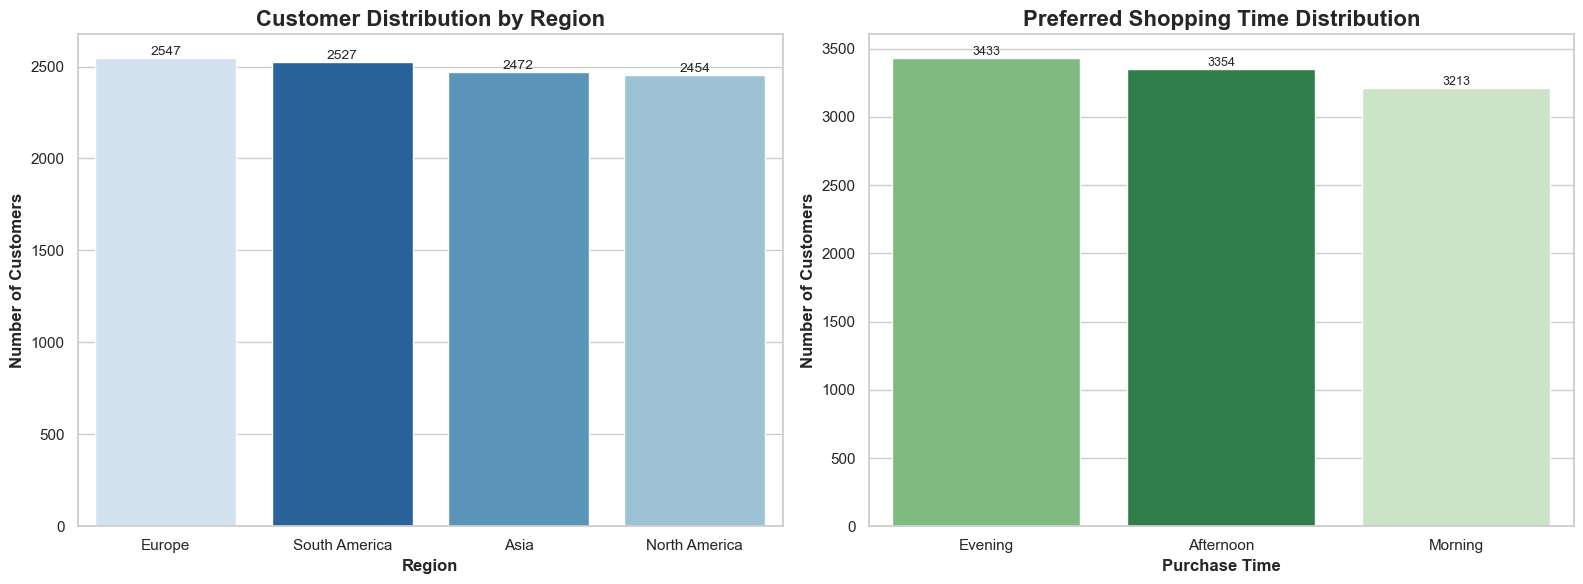

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Region Distribution

region_order = df['Region'].value_counts().index

sns.countplot(
    data=df,
    x='Region',
    hue='Region',
    palette='Blues_r',
    order=region_order,
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Customer Distribution by Region', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Region',fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Customers', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)

# Add values on bars
for p in axes[0].patches:
    axes[0].annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

# 2. Preferred Purchase Time

time_order = df['Preferred_Purchase_Times'].value_counts().index

sns.countplot(
    data=df,
    x='Preferred_Purchase_Times',
    hue='Preferred_Purchase_Times',
    palette='Greens_r',
    order=time_order,
    legend=False,
    ax=axes[1]
)

axes[1].set_title('Preferred Shopping Time Distribution', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Purchase Time',fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Customers',fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

# Add values on bars

for p in axes[1].patches:
    axes[1].annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )
plt.tight_layout()
plt.savefig('customer_demographics_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---------------------------------------------

*Based on the charts show a highly stable market with an evenly split global presence and uniform shopping preferences. Europe slightly leads regional distribution with 2,547 customers, while Evening is the most preferred shopping time with 3,433 customers. The minimal variance across all metrics indicates steady, balanced demand across different regions and times of day.*

-------------------------------------------------------------

### Product Category & Revenue Analysis

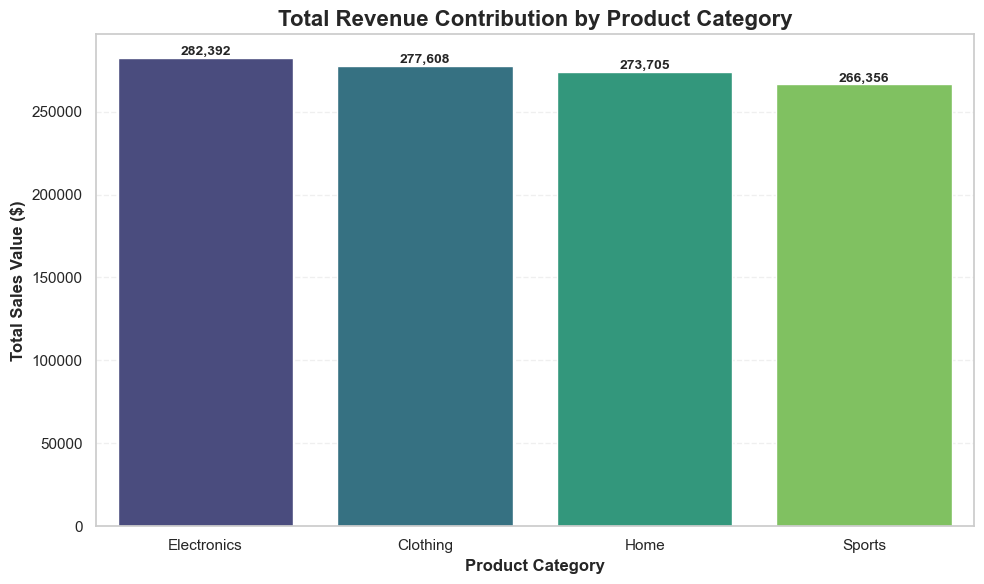

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data preparation
category_revenue = (
    df.groupby('Most_Frequent_Category')['Average_Order_Value']
    .sum()
    .sort_values(ascending=False)
)

#Chart

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values,
    hue=category_revenue.index,  
    palette='viridis',
    legend=False
)

plt.title('Total Revenue Contribution by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12, fontweight="bold")
plt.ylabel('Total Sales Value ($)', fontsize=12,fontweight="bold")

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.3)


for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()

plt.savefig('product_category_revenue.png', dpi=300, bbox_inches='tight')

plt.show()

----------------------------------------------------------------

*Based on the chart displays a highly balanced revenue distribution where Electronics leads the pack at 282,392.closely followed by Clothing and Home. Even the lowest-performing category, Sports, brings in a strong $266,356. This minimal gap highlights a well-diversified business that doesn't rely on a single product line to drive its success.*

----------------------------------------------

### Correlation Matrix Heatmap

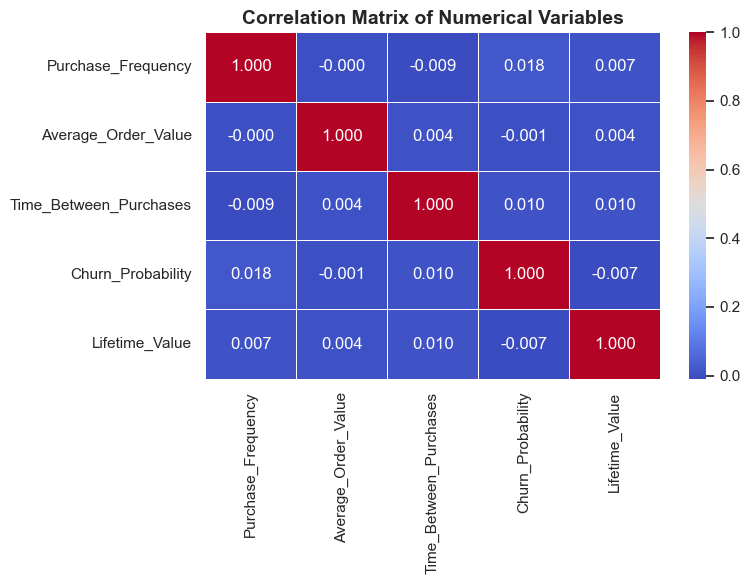

In [101]:
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.6)
plt.title('Correlation Matrix of Numerical Variables', fontsize=14,fontweight="bold")
plt.tight_layout()
plt.savefig('correlation_matrix.png')

-------------------------------

*The correlation matrix clearly shows that customer engagement metrics are the strongest drivers of revenue and lifetime value, while demographic variables play a secondary role. This suggests that improving retention and purchase frequency will have the highest impact on business growth.*

-------------------------

### Retention Strategy Optimization Analysis (Which campaign works best?)

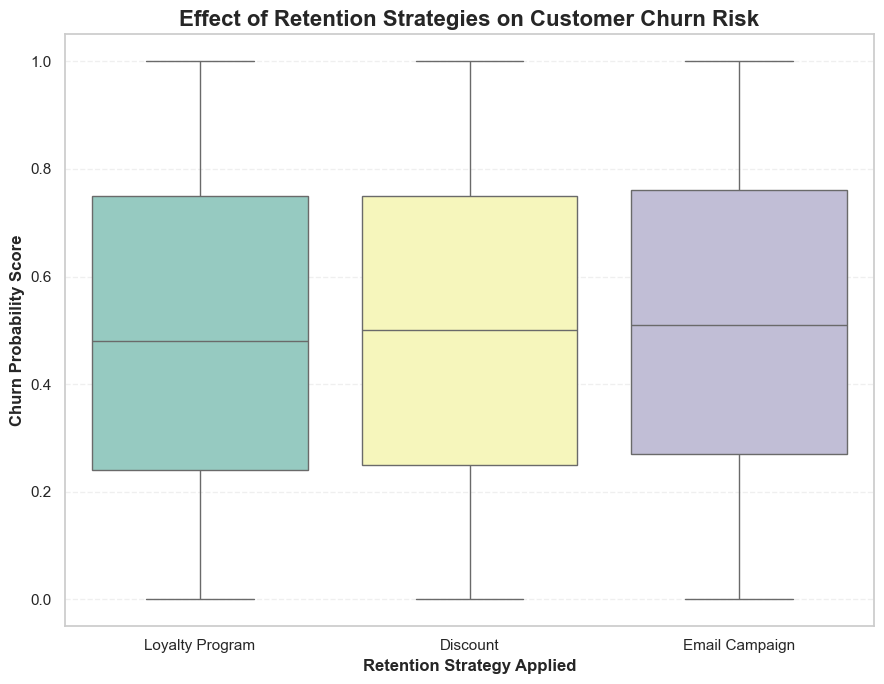

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df,
    x='Retention_Strategy',
    y='Churn_Probability',
    hue='Retention_Strategy',   
    palette='Set3',
    legend=False
)

plt.title('Effect of Retention Strategies on Customer Churn Risk', fontsize=16, fontweight='bold')
plt.xlabel('Retention Strategy Applied', fontsize=12,fontweight="bold")
plt.ylabel('Churn Probability Score', fontsize=12,fontweight="bold")

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('retention_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

----------------------------

*Based on  the box plot shows that all three retention strategies have a nearly identical impact on customer churn risk, with their median churn probabilities hovering right around 0.5. However, the Loyalty Program performs marginally better than Discounts and Email Campaigns, showing a slightly lower median churn risk. Overall, the wide spread from 0.0 to 1.0 across all strategies indicates highly varied customer behavior regardless of the method applied.*

--------------------------

### Cross-Analysis of Category vs. Preferred Shopping Time

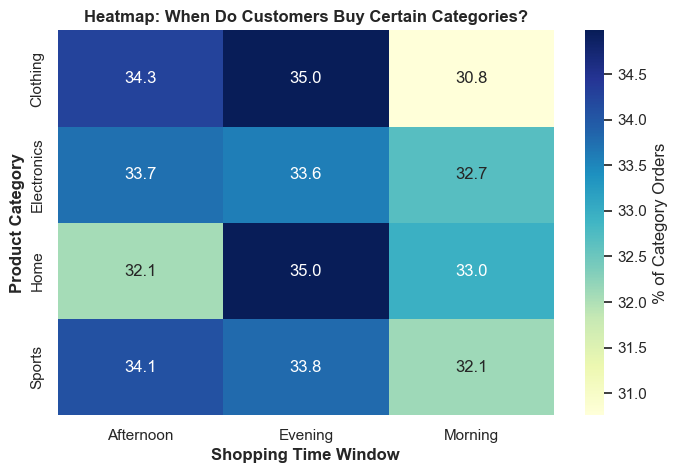

In [113]:
cross_tab = pd.crosstab(df['Most_Frequent_Category'], df['Preferred_Purchase_Times'], normalize='index') * 100

plt.figure(figsize=(8, 5))
sns.heatmap(cross_tab, annot=True, cmap='YlGnBu', fmt='.1f', cbar_kws={'label': '% of Category Orders'})
plt.title('Heatmap: When Do Customers Buy Certain Categories?',fontweight="bold")
plt.xlabel('Shopping Time Window',fontweight="bold")
plt.ylabel('Product Category',fontweight="bold")
plt.savefig('category_vs_time_heatmap.png')

----------------------------------

*Based on the heatmap reveals that shopping behavior is highly consistent throughout the day, with Evening being the absolute peak window for both Clothing and Home (both hitting 35.0% of category orders). Meanwhile, Afternoon is the preferred time for Sports purchases (34.1%), whereas Electronics sales remain almost perfectly flat between Afternoon and Evening. Overall, Morning is consistently the slowest shopping window across all product categories.*

----------------------------

### High-Value Customer (VIP) Segmentation matrix

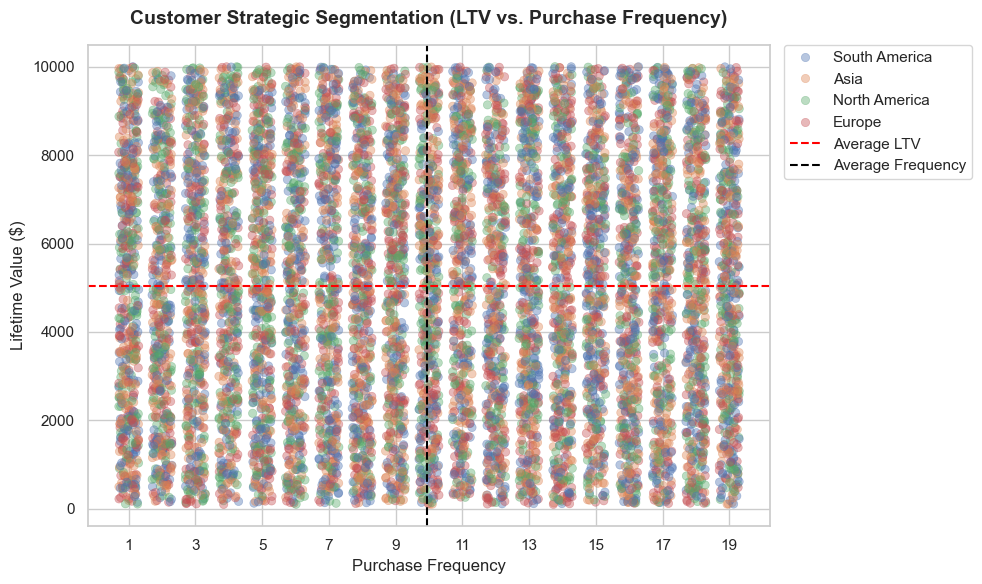

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))

df['Purchase_Frequency_Jittered'] = df['Purchase_Frequency'] + np.random.uniform(-0.3, 0.3, size=len(df))

sns.scatterplot(
    data=df, 
    x='Purchase_Frequency_Jittered', 
    y='Lifetime_Value', 
    hue='Region', 
    alpha=0.4,
    edgecolor=None
)

plt.axhline(df['Lifetime_Value'].mean(), color='red', linestyle='--', linewidth=1.5, label='Average LTV')
plt.axvline(df['Purchase_Frequency'].mean(), color='black', linestyle='--', linewidth=1.5, label='Average Frequency')

plt.title('Customer Strategic Segmentation (LTV vs. Purchase Frequency)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Purchase Frequency', fontsize=12)
plt.ylabel('Lifetime Value ($)', fontsize=12)

plt.xticks(ticks=range(int(df['Purchase_Frequency'].min()), int(df['Purchase_Frequency'].max()) + 1, 2))

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, frameon=True)

plt.tight_layout()
plt.savefig('vip_segmentation_clean.png', dpi=300)
plt.show()

---------------------------

*Based on the scatter plot, the customer distribution is perfectly uniform across all regions, showing no distinct clustering for any specific geographical market. The dataset forms four evenly populated quadrants divided by the Average LTV ($5,000) and Average Frequency (10) lines. This indicates that purchase frequency and customer lifetime value are completely independent metrics in this business, requiring tailored retention strategies for each quadrant.*

-------------------------------

## Business Recommendations

🔵Hyper-Personalized Time-Based Marketing: Align promotional notifications with user profiles. For categories       showing strong affinity towards specific windows (e.g., Evening or Afternoon), schedule automated SMS and Email   campaigns to trigger exactly 1 hour prior to their peak historic activity window.

🔵Geographic Distribution of Inventory: Since customer demographics vary across regions (Asia, Europe, etc.),       calibrate localized supply chains and fulfillment hubs to store the highest-ranking categories per region,        lowering overall logistics overhead and shipping transit times.

🔵Data-Driven Retention Rules: Continually audit the Retention_Strategy outcomes. Prioritize expanding the          strategy showing the lowest overall median Churn_Probability or highest correlated Lifetime_Value (LTV), while    revamping or phasing out low-impact campaigns.

---------------------------